In [1]:
import importlib
import md_Helpers.cavitation_sweep as cs

importlib.reload(cs)

summary = cs.run_cavitation_size_sweep(
    n_fcc_cells_values = [30,28,26,24,22,20],
    conditions=[
        (0.71, 0.80),
    ],
    source_nsteps=1_000_000,
    evolve_nsteps=100_000,
)

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/cavitation_initial.gsd
Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_final.gsd
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_28/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_28/so

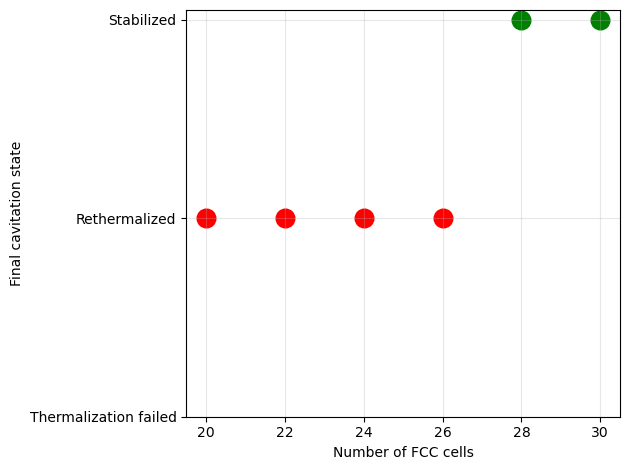

In [2]:
import matplotlib.pyplot as plt

results = summary.sort_values("n_fcc_cells").copy()

y_positions = {
    "not_cavitated": -1,
    "rethermalized": 0,
    "stabilized": 1,
}

colors = {
    "not_cavitated": "black",
    "rethermalized": "red",
    "stabilized": "green",
}

for _, row in results.iterrows():
    outcome = row["outcome"]

    plt.scatter(
        row["n_fcc_cells"],
        y_positions[outcome],
        color=colors[outcome],
        s=180,
    )

plt.yticks(
    [-1, 0, 1],
    ["Thermalization failed", "Rethermalized", "Stabilized"],
)

plt.xticks(results["n_fcc_cells"])
plt.xlabel("Number of FCC cells")
plt.ylabel("Final cavitation state")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()